In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import re

In [23]:
data_df = pd.read_csv('./data/emails.csv', sep=',')
df = pd.DataFrame({
    'Text' : data_df['text'],
    'Class' : data_df['spam'],
})

In [24]:
df.shape

(5728, 2)

In [25]:
df.head(10)
df.value_counts()

Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

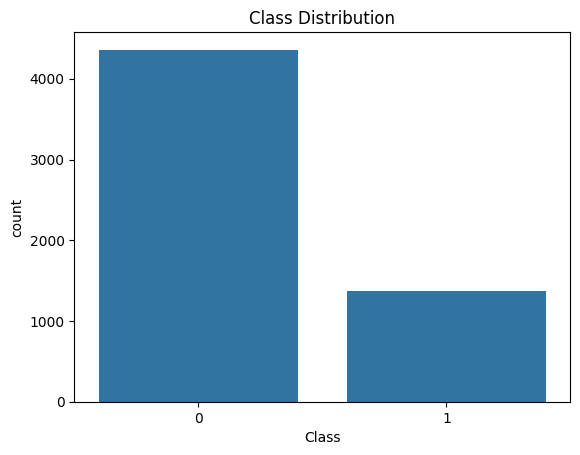

In [26]:
sns.countplot(data=df, x='Class')
plt.title('Class Distribution')
plt.show()

In [27]:
prefix = 'Subject: '
df['Text'] = df['Text'].str.removeprefix(prefix)

df = df.where((pd.notnull(df)), '')

df.head(10)

,Text,Class
0,naturally irresistible your corporate identity...,1
1,the stock trading gunslinger fanny is merrill...,1
2,unbelievable new homes made easy im wanting t...,1
3,4 color printing special request additional i...,1
4,"do not have money , get software cds from here...",1
5,"great nnews hello , welcome to medzonline sh ...",1
6,here ' s a hot play in motion homeland securi...,1
7,save your money buy getting this thing here y...,1
8,undeliverable : home based business for grownu...,1
9,save your money buy getting this thing here y...,1


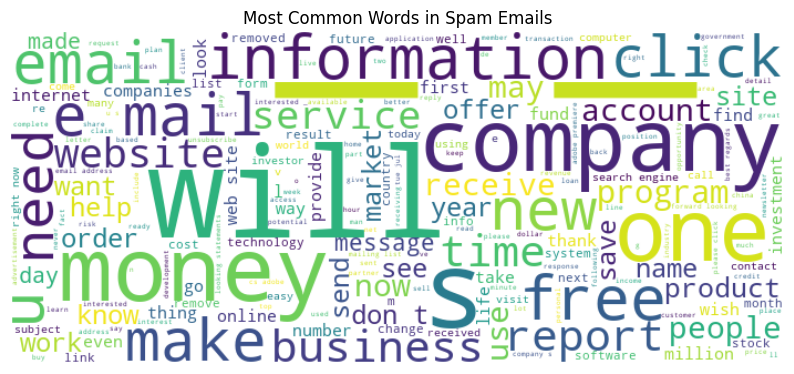

In [28]:
spam_text = ' '.join(df[df['Class'] == 1]['Text'])

wc = WordCloud(
    background_color="White",
    stopwords=STOPWORDS,
    height=300,
    width=700,
)

wc.generate(spam_text)

plt.figure(figsize=(10, 12))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam Emails')
plt.show()

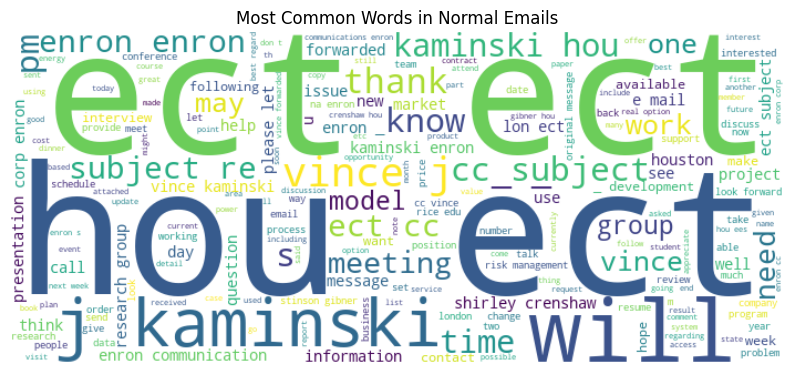

In [29]:
spam_text = ' '.join(df[df['Class'] == 0]['Text'])

wc = WordCloud(
    background_color="White",
    stopwords=STOPWORDS,
    height=300,
    width=700,
)

wc.generate(spam_text)

plt.figure(figsize=(10, 12))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Normal Emails")
plt.show()

In [30]:
X = df.Text
Y = df.Class

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=12)

In [32]:
feature_extraction = TfidfVectorizer(min_df= 1, stop_words= "english", lowercase= True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

In [33]:
model = LogisticRegression()

In [34]:
model.fit(X_train_features, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
prediction_Y = model.predict(X_train_features)
acc = accuracy_score(Y_train, prediction_Y)
print(acc)

0.9969445656918376


In [36]:
prediction_Y_test = model.predict(X_test_features)
acc = accuracy_score(Y_test, prediction_Y_test)
print(acc)

0.9895287958115183


In [37]:
precision_score(Y_test, prediction_Y_test)

0.9817518248175182

In [38]:
recall_score(Y_test, prediction_Y_test)

0.9746376811594203

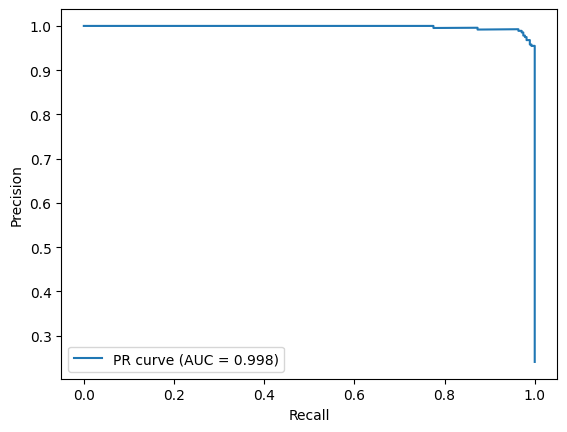

In [39]:
Y_Scores = model.predict_proba(X_test_features)[:, 1]
precision, recall, thresholds = precision_recall_curve(Y_test, Y_Scores)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(); plt.show()

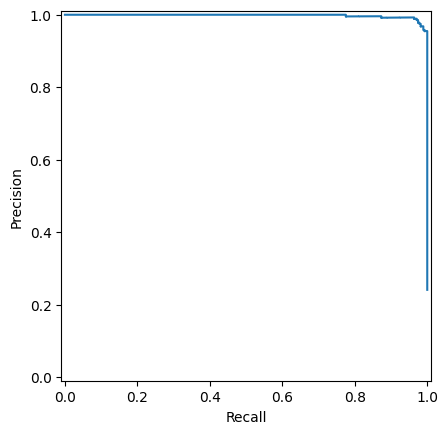

In [40]:
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

In [41]:
cm = confusion_matrix(Y_test, prediction_Y_test)
print(cm)

[[865   5]
 [  7 269]]


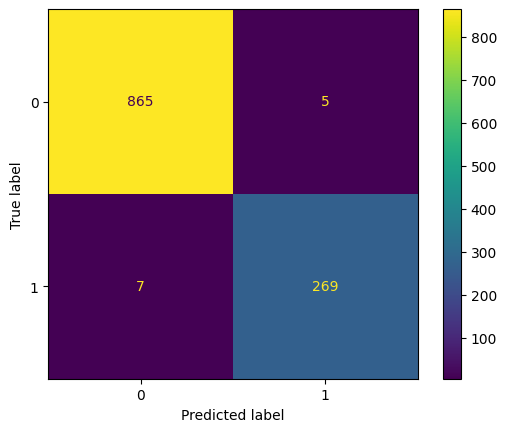

In [42]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()